### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### **Goal**
Determine which features have the most influence over the sale price of used cars. The goal is to build an understanding of the data and to be able to interpret the value of various independent variables in how much they affect the sale price as a dependent variable.

#### **Methodology**
Develop a supervised regression model targeting the sale price of used vehicles, then interpret the fitted model through coefficient analyses to determine which features have the largest impact on sale price.

#### **Validation Strategy**
Use strategies such as a train-test split or k-fold cross validation and measuring the RMSE and MAE to determine the effectiveness of the fitted model not only against the training data but against simulated real-world data as well.

#### Exploring the Data
The first steps in understanding the dataset is to examine the features. I will use dataframe.head() and dataframe.info() to get an understanding of the shape of the data. I will then attempt to discover how much of the data is missing, looking for columns that have a significant number of NaN values. I will also put together plots like histograms of various features of the dataset to start to understand the distribution of values in the data.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / 'data' / 'vehicles.csv'
ART_PATH  = ROOT / 'artifacts'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import evaluate, CLUSTER_LABELS, NUMERIC_COLS

df = pd.read_csv('../data/vehicles.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [3]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


               count    percent
id                 0   0.000000
region             0   0.000000
price              0   0.000000
year            1205   0.282281
manufacturer   17646   4.133714
model           5277   1.236179
condition     174104  40.785232
cylinders     177678  41.622470
fuel            3013   0.705819
odometer        4400   1.030735
title_status    8242   1.930753
transmission    2556   0.598763
VIN           161042  37.725356
drive         130567  30.586347
size          306361  71.767476
type           92858  21.752717
paint_color   130203  30.501078
state              0   0.000000


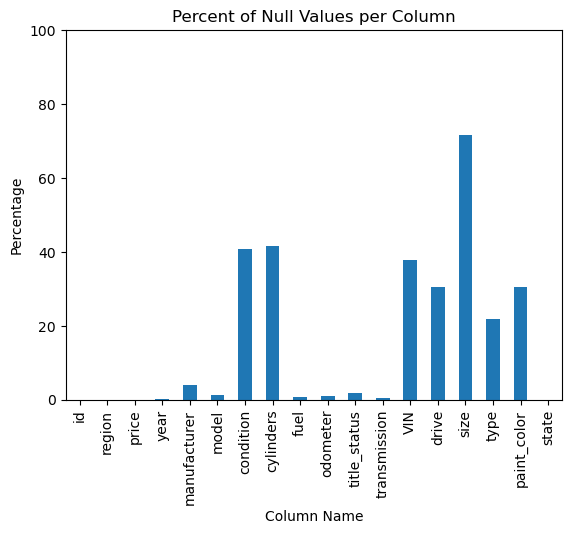

In [4]:
count_null = df.isnull().sum()
null_summary = pd.DataFrame({'count': count_null, 'percent': (count_null / len(df)) * 100})

print(null_summary)
null_summary['percent'].plot(kind='bar', ylim=(0, 100))
plt.title("Percent of Null Values per Column")
plt.xlabel("Column Name")
plt.ylabel("Percentage")
#plt.xticks(rotation=45)
plt.show()

In [5]:
df[df['price'] > 0]['price'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .995, .999])

count    3.939850e+05
mean     8.147763e+04
std      1.268064e+07
min      1.000000e+00
1%       1.500000e+02
5%       1.988000e+03
25%      7.000000e+03
50%      1.500000e+04
75%      2.759000e+04
95%      4.499900e+04
99%      6.874748e+04
99.5%    7.890000e+04
99.9%    1.234560e+05
max      3.736929e+09
Name: price, dtype: float64

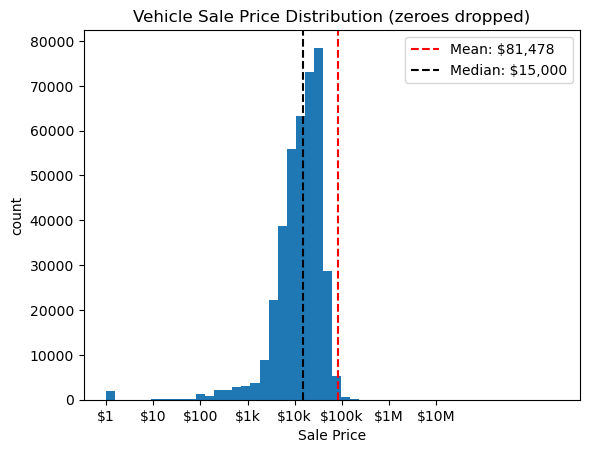

In [6]:
price = df[(df['price'] > 0)]['price']
log_price = np.log(price)

mean = price.mean()
median = price.median()

plt.hist(log_price, bins=50)
ticks = [np.log(v) for v in [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]]
labels = ['$1', '$10', '$100', '$1k', '$10k', '$100k', '$1M', '$10M']
plt.title("Vehicle Sale Price Distribution (zeroes dropped)")
plt.axvline(np.log(mean),   color='red',   linestyle='--', label=f'Mean: ${mean:,.0f}')
plt.axvline(np.log(median), color='black', linestyle='--', label=f'Median: ${median:,.0f}')
plt.xlabel("Sale Price")
plt.xticks(ticks, labels)
plt.ylabel("count")
plt.legend()
plt.show()
#log_price.head()

In [7]:
df['odometer'].describe()

count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64

In [8]:
df['year'].describe()

count    425675.000000
mean       2011.235191
std           9.452120
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

In [9]:
print("num unique models: %s" % df['model'].nunique())
print("num unique regions: %s" % df['region'].nunique())
print("num unique manufacturers: %s" % df['manufacturer'].nunique())
print("num unique conditions: %s" % df['condition'].nunique())
print("num unique cylinders: %s" % df['cylinders'].nunique())
print("num unique fuels: %s" % df['fuel'].nunique())
print("num unique title_status: %s" % df['title_status'].nunique())
print("num unique transmissions: %s" % df['transmission'].nunique())
print("num unique drives: %s" % df['drive'].nunique())
print("num unique types: %s" % df['type'].nunique())
print("num unique paint_colors: %s" % df['paint_color'].nunique())
print("num unique states: %s" % df['state'].nunique())

num unique models: 29649
num unique regions: 404
num unique manufacturers: 42
num unique conditions: 6
num unique cylinders: 8
num unique fuels: 5
num unique title_status: 6
num unique transmissions: 3
num unique drives: 3
num unique types: 13
num unique paint_colors: 12
num unique states: 51


In [10]:
df['size'].unique()

array([nan, 'full-size', 'mid-size', 'compact', 'sub-compact'],
      dtype=object)

In [11]:
drop_null_rows = df.dropna(subset=['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission'])
dropped_percent = ((len(df) - len(drop_null_rows)) / len(df)) * 100
print("percent of rows dropped with null values: %s" % dropped_percent)

percent of rows dropped with null values: 8.7321964017991


In [12]:
nulls = df['odometer'].isna().sum()
zeros = (df['odometer'] == 0).sum()
high  = (df['odometer'] > 400_000).sum()
print("odometer values")
print(f"null: {nulls:,} ({nulls/len(df):.2%})")
print(f"zero: {zeros:,} ({zeros/len(df):.2%})")
print(f">400k: {high:,} ({high/len(df):.2%})")

odometer values
null: 4,400 (1.03%)
zero: 1,965 (0.46%)
>400k: 1,702 (0.40%)


#### **Exploration Conclusions**

##### **Columns**
The dataset contains 18 columns: id, region, price, year, manufacturer, model, condition, cylinders, fuel, odometer, title_status, transmission, VIN, drive, size, type, paint_color, state

##### **Null Values**
My initial analysis shows that some columns of this dataset have a significant percentage of null values. These are 'size', 'condition', 'cylinders', 'VIN', 'drive', 'type' and 'paint_color', with 'size' having the most null values out of all columns. I believe that the 'VIN' column can be dropped completely as it likely has no real impact on the sale price, 'size' can also likely be dropped as it is about 72% null values. All of the other columns that have a significant number of null values will likely have their nulls replaced with a 'missing' value, I think it may be possible that the fact that a listing is missing one or more of these values may have an impact on how much customers are willing to pay for them.

Some columns contain more insignificant numbers of null values. these are 'year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status' and 'transmission'. All of these contain less than 5% null values and most of them contain ~1% null values, so I believe that it is possible to simply drop all of the rows that contain null values for these columns. Dropping the null values in these columns only reduces the total rows in the dataset by 8%.

##### **Price**
The price data will need to be cleaned up considerably. About 5% of the given prices are zero, and there are a significant number of outlier values, such as the largest price which is $3.7B. The data will need to be clipped to get rid of the zeroes and the outliers. The 99th percentile price is $68,747 so I believe that this would be a fair upper bound to cut off the higher outliers. The analysis above used a log transformation of the price data to make it more readable in plots, this may or may not be necessary after removing all of the extreme outliers.

##### **Year**
The minimum year value of 1900 seems to be a placeholder or default value, so these entries should be filtered out as well. After dopping anything older than about 1920, I will also engineer a new column for 'age', this will make linear regression models easier to build because a raw 'year' value will be difficult for the model to directly learn from, whereas the model can directly use an 'age' value mathematically.

I'll also note that while in general, newer cars are worth more than older ones, this is not the case for 'classic' cars. Older classic cars can actually increase in price as they get older, so a linear model with have difficulty modeling this correctly. To solve for this, I plan to actually drop any rows older than 1980, removing these classic cars from the dataset as they skew the results for the vehicles that we are actually interested in. However, in the future I suspect that using clustering algorithms to attempt to classify car types into 'normal' and 'classic' among other types could be another solution to this problem.

##### **Odometer**
The max odometer value of 10,000,000 is not a feasible value for a real vehicle, so this will also need to be filtered. Entries with an odometer value of zero are most likely either typos or default values, since a used car should not ever be brand new. Because of this, I will drop all rows with an odometer value of zero. For the impossibly high odometer values I will just clip their values to the 99.5 percentile odometer value of the dataset (about 300,000 miles).

##### **Model, Region, Manufacturer and States**
These categorical features will need to be encoded in order to be useful to the model. In particular, the 'model' feature has almost 30,000 unique values, so one-hot encoding for this feature will not be feasible, a different encoding method like target encoding will need to be used.

##### **All Other Categorical Features**
All of the other categorical features other than 'Model', 'Region', 'Manufacturer' and 'States' will be encoded using one-hot encoding.

In [13]:
# dropping unneccessary columns VIN and size
vehicles_clean = df.drop(columns=['VIN', 'size', 'id', 'region'])

# drop rows containing null from columns with few nulls
vehicles_clean = vehicles_clean.dropna(subset=['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission'])

# replace null values in some columns with 'missing'
vehicles_clean = vehicles_clean.fillna("missing")

vehicles_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389604 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         389604 non-null  int64  
 1   year          389604 non-null  float64
 2   manufacturer  389604 non-null  object 
 3   model         389604 non-null  object 
 4   condition     389604 non-null  object 
 5   cylinders     389604 non-null  object 
 6   fuel          389604 non-null  object 
 7   odometer      389604 non-null  float64
 8   title_status  389604 non-null  object 
 9   transmission  389604 non-null  object 
 10  drive         389604 non-null  object 
 11  type          389604 non-null  object 
 12  paint_color   389604 non-null  object 
 13  state         389604 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 44.6+ MB


In [14]:
# filter the price data, remove zeroes and prices above the 99th percentile
price_percentile_99 = vehicles_clean['price'].describe(percentiles=[.99])['99%']
vehicles_clean = vehicles_clean[(vehicles_clean['price'] > 0) & (vehicles_clean['price'] < price_percentile_99)]

vehicles_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 357095 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         357095 non-null  int64  
 1   year          357095 non-null  float64
 2   manufacturer  357095 non-null  object 
 3   model         357095 non-null  object 
 4   condition     357095 non-null  object 
 5   cylinders     357095 non-null  object 
 6   fuel          357095 non-null  object 
 7   odometer      357095 non-null  float64
 8   title_status  357095 non-null  object 
 9   transmission  357095 non-null  object 
 10  drive         357095 non-null  object 
 11  type          357095 non-null  object 
 12  paint_color   357095 non-null  object 
 13  state         357095 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 40.9+ MB


In [15]:
# filter the odometer values, drop zeroes and cap values above the 99.5th percentile
od_percentile_995 = vehicles_clean['odometer'].describe(percentiles=[.995])['99.5%']
vehicles_clean = vehicles_clean[vehicles_clean['odometer'] > 0]
vehicles_clean['odometer'] = vehicles_clean['odometer'].clip(upper=od_percentile_995)

print(od_percentile_995)
print(vehicles_clean['odometer'].describe())
vehicles_clean.info()

303295.65999999933
count    356455.000000
mean      93430.700085
std       63049.200785
min           1.000000
25%       39385.000000
50%       88241.000000
75%      136000.000000
max      303295.660000
Name: odometer, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 356455 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         356455 non-null  int64  
 1   year          356455 non-null  float64
 2   manufacturer  356455 non-null  object 
 3   model         356455 non-null  object 
 4   condition     356455 non-null  object 
 5   cylinders     356455 non-null  object 
 6   fuel          356455 non-null  object 
 7   odometer      356455 non-null  float64
 8   title_status  356455 non-null  object 
 9   transmission  356455 non-null  object 
 10  drive         356455 non-null  object 
 11  type          356455 non-null  object 
 12  paint_color   356455 non-null  object 

In [16]:
# drop rows with year older than 1980
vehicles_clean = vehicles_clean[vehicles_clean['year'] >= 1980]

# create a new column for 'age' and drop the 'year'
current_year = 2026
vehicles_clean['age'] = current_year - vehicles_clean['year']
vehicles_clean = vehicles_clean.drop(columns=['year'])

vehicles_clean.head()

,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,age
27,33590,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,missing,pickup,white,al,12.0
28,22590,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,missing,pickup,blue,al,16.0
29,39590,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,missing,pickup,red,al,6.0
30,30990,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,missing,pickup,red,al,9.0
31,15000,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,13.0


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# declare all of the features that will be one-hot encoded
oh_features = ['condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'manufacturer', 'state']

transformer = ColumnTransformer(
  transformers=[
    ('oh_encoder', OneHotEncoder(sparse_output=False), oh_features)
  ],
  remainder='passthrough',
  verbose_feature_names_out=False
)

vehicles_ohe = pd.DataFrame(transformer.fit_transform(vehicles_clean), columns=transformer.get_feature_names_out(), index=vehicles_clean.index)
vehicles_ohe.head()

,condition_excellent,condition_fair,condition_good,condition_like new,condition_missing,condition_new,condition_salvage,cylinders_10 cylinders,cylinders_12 cylinders,cylinders_3 cylinders,...,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,price,model,odometer,age
27,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,33590,sierra 1500 crew cab slt,57923.0,12.0
28,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,22590,silverado 1500,71229.0,16.0
29,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,39590,silverado 1500 crew,19160.0,6.0
30,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,30990,tundra double cab sr,41124.0,9.0
31,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,15000,f-150 xlt,128000.0,13.0


In [18]:
from sklearn.model_selection import train_test_split

# split the price column into a separate dataframe
price = vehicles_ohe['price']
vehicles_ohe = vehicles_ohe.drop(columns=['price'])

# create train and test datasets
X_train, X_test, y_train, y_test = train_test_split(vehicles_ohe, price, test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder(target_type='continuous', smooth='auto', random_state=42)

# fit_transform uses 5-fold cross-fitting on training data automatically (no leakage)
# transform on test uses the full-training-set encoding
X_train['model'] = encoder.fit_transform(X_train[['model']], y_train).ravel()
X_test['model']  = encoder.transform(X_test[['model']]).ravel()

X_train['model'] = X_train['model'].astype(float)
X_test['model']  = X_test['model'].astype(float)

X_train.head()

,condition_excellent,condition_fair,condition_good,condition_like new,condition_missing,condition_new,condition_salvage,cylinders_10 cylinders,cylinders_12 cylinders,cylinders_3 cylinders,...,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,model,odometer,age
362085,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34621.357591,9624.0,6.0
291636,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4048.922763,178894.0,21.0
148986,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3250.000000,126000.0,21.0
331346,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26858.783234,41816.0,9.0
286120,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22535.891708,30478.0,7.0


In [20]:
# create a log-dollars version of the training target data
y_train = y_train.astype(float)
y_test = y_test.astype(float)
y_train_log = np.log(y_train)

In [21]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Use the same X_train but standardize (KMeans is distance-based)
scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_train)

print(f"Clustering on shape: {X_cluster.shape}")

Clustering on shape: (280845, 156)


Cumulative variance explained at 20 components: 23.53%


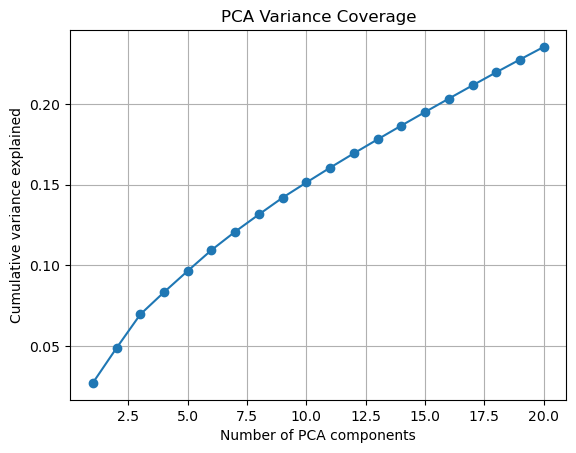

In [22]:
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_cluster)

cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f"Cumulative variance explained at 20 components: {cumvar[-1]:.2%}")

plt.plot(range(1, 21), cumvar, marker='o')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative variance explained')
plt.title('PCA Variance Coverage')
plt.grid(True)
plt.show()

K=2: inertia=1,682,601, silhouette=0.101
K=3: inertia=1,576,318, silhouette=0.096
K=4: inertia=1,434,022, silhouette=0.119
K=5: inertia=1,388,696, silhouette=0.120
K=6: inertia=1,374,496, silhouette=0.121
K=7: inertia=1,255,689, silhouette=0.133
K=8: inertia=1,287,246, silhouette=0.121
K=9: inertia=1,212,168, silhouette=0.111
K=10: inertia=1,167,226, silhouette=0.118


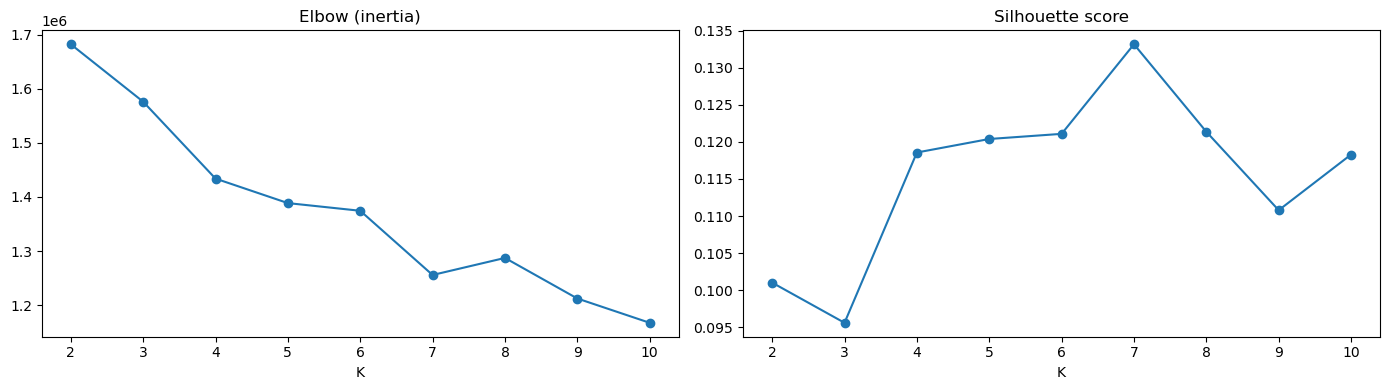

In [23]:
sample_idx = np.random.RandomState(42).choice(len(X_pca), size=50_000, replace=False)
X_sample = X_pca[sample_idx]

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=4096)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels, sample_size=10_000, random_state=42))
    print(f"K={k}: inertia={km.inertia_:,.0f}, silhouette={silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(k_range, inertias, marker='o'); axes[0].set_title('Elbow (inertia)'); axes[0].set_xlabel('K')
axes[1].plot(k_range, silhouettes, marker='o'); axes[1].set_title('Silhouette score'); axes[1].set_xlabel('K')
plt.tight_layout(); plt.show()

In [24]:
K = 8  # pick based on elbow + silhouette + interpretability

kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, n_init=10, batch_size=4096)
clusters_train = kmeans.fit_predict(X_pca)

# Apply same transforms to test set
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
clusters_test = kmeans.predict(X_test_pca)

# Attach cluster labels back to the original dataframes for profiling
X_train_labeled = X_train.copy()
X_train_labeled['cluster'] = clusters_train
X_train_labeled['price']   = y_train.values

print(X_train_labeled['cluster'].value_counts().sort_index())

cluster
0    52538
1    40394
2    17861
3    31895
4    36672
5    37214
6    46133
7    18138
Name: count, dtype: int64


In [25]:
for c in sorted(X_train_labeled['cluster'].unique()):
    sub = X_train_labeled[X_train_labeled['cluster'] == c]
    print(f"\n=== Cluster {c} ({len(sub):,} rows, {len(sub)/len(X_train_labeled):.1%}) ===")
    print(f"  Price: median ${sub['price'].median():,.0f}, mean ${sub['price'].mean():,.0f}")
    print(f"  Age:   median {sub['age'].median():.1f} years")
    print(f"  Odo:   median {sub['odometer'].median():,.0f} miles")
    print(f"  Model encoding: median ${sub['model'].median():,.0f}")

    # Most distinctive one-hot features for this cluster
    cat_cols = [c for c in X_train.columns if any(c.startswith(p) for p in
        ['manufacturer_', 'type_', 'condition_', 'fuel_', 'cylinders_', 'title_status_'])]
    cluster_means  = sub[cat_cols].mean()
    overall_means  = X_train_labeled[cat_cols].mean()
    diff           = (cluster_means - overall_means).sort_values(ascending=False)
    print(f"  Top distinctive features: {', '.join(diff.head(5).index.tolist())}")


=== Cluster 0 (52,538 rows, 18.7%) ===
  Price: median $9,700, mean $12,232
  Age:   median 15.0 years
  Odo:   median 115,501 miles
  Model encoding: median $12,916
  Top distinctive features: cylinders_6 cylinders, condition_excellent, type_SUV, fuel_gas, manufacturer_jeep

=== Cluster 1 (40,394 rows, 14.4%) ===
  Price: median $18,000, mean $20,516
  Age:   median 14.0 years
  Odo:   median 109,527 miles
  Model encoding: median $22,536
  Top distinctive features: cylinders_8 cylinders, type_truck, manufacturer_chevrolet, manufacturer_ford, type_pickup

=== Cluster 2 (17,861 rows, 6.4%) ===
  Price: median $32,499, mean $32,066
  Age:   median 13.0 years
  Odo:   median 119,966 miles
  Model encoding: median $29,782
  Top distinctive features: fuel_diesel, manufacturer_ford, type_truck, manufacturer_ram, condition_missing

=== Cluster 3 (31,895 rows, 11.4%) ===
  Price: median $29,590, mean $29,550
  Age:   median 8.0 years
  Odo:   median 24,238 miles
  Model encoding: median $28,

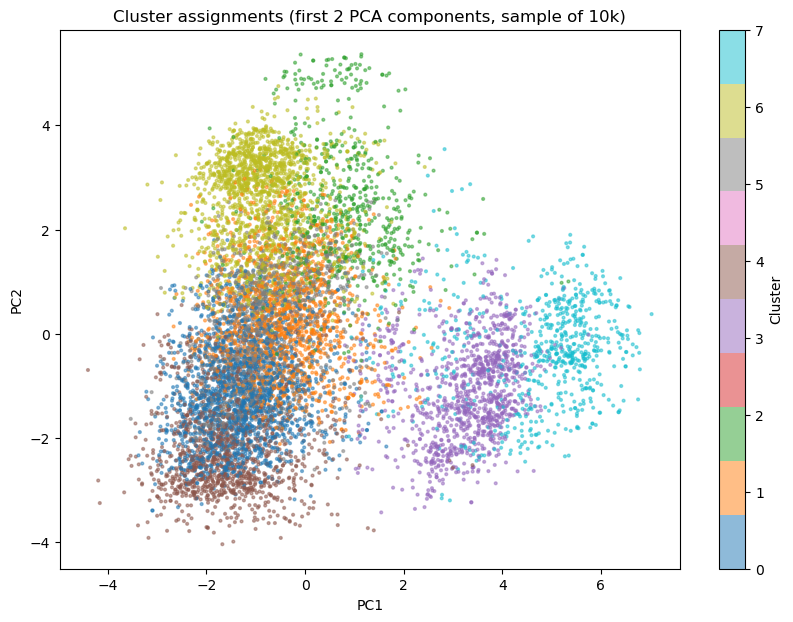

In [26]:
plt.figure(figsize=(10, 7))
sample_idx = np.random.RandomState(42).choice(len(X_pca), size=10_000, replace=False)
plt.scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
            c=clusters_train[sample_idx], cmap='tab10', s=4, alpha=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Cluster assignments (first 2 PCA components, sample of 10k)')
plt.colorbar(label='Cluster')
plt.show()

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:25s}  RMSE: ${rmse:>8,.0f}   MAE: ${mae:>8,.0f}   R²: {r2:.3f}")

# Baseline: predict median price for every row
median_pred = np.full_like(y_test, fill_value=y_train.median(), dtype=float)
evaluate("Baseline (median)", y_test, median_pred)

Baseline (median)          RMSE: $  13,455   MAE: $  10,672   R²: -0.043


In [28]:
# fit a simple linear regression model on the data
linreg = LinearRegression()
linreg.fit(X_train, y_train_log)

# because the y data is log transformed, we need to convert it back with exp to be able to evaluate it
preds_lr = np.exp(linreg.predict(X_test))
evaluate("Linear Regression", y_test, preds_lr)

Linear Regression          RMSE: $   8,497   MAE: $   5,485   R²: 0.584


In [29]:
# create a pipeline to fit a ridge model
ridge_pipe = Pipeline([
  ('scaler', StandardScaler()),
  ('ridge', RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]))
])

ridge_pipe.fit(X_train, y_train_log)

preds_ridge = np.exp(ridge_pipe.predict(X_test))

# pull out the alpha value that was chosen by RidgeCV
chosen_alpha = ridge_pipe.named_steps['ridge'].alpha_
print(f"Chosen alpha: {chosen_alpha}")

evaluate("Ridge", y_test, preds_ridge)

Chosen alpha: 1000.0
Ridge                      RMSE: $   8,473   MAE: $   5,479   R²: 0.586


In [30]:
### another ridge model that also uses polynomial features on a small number of numeric features

all_other_cols = [c for c in X_train.columns if c not in NUMERIC_COLS]

# Pipeline for numeric columns: scale, then add polynomial terms
numeric_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_COLS),
    ('cat', StandardScaler(), all_other_cols),  # just scale the one-hots, no polynomials
])

ridge_poly = Pipeline([
    ('preprocess', preprocessor),
    ('ridge',      RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0])),
])

ridge_poly.fit(X_train, y_train_log)
preds_ridge_poly = np.exp(ridge_poly.predict(X_test))

chosen_alpha = ridge_poly.named_steps['ridge'].alpha_
print(f"Chosen alpha: {chosen_alpha}")

evaluate("Ridge + Polynomial (numeric only)", y_test, preds_ridge_poly)

Chosen alpha: 100.0
Ridge + Polynomial (numeric only)  RMSE: $   7,614   MAE: $   5,128   R²: 0.666


In [31]:
# create a pipeline to fit a lasso model
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  LassoCV(alphas=[0.001, 0.01, 0.1, 0.5], cv=5, max_iter=5000)),
])

lasso_pipe.fit(X_train, y_train_log)

preds_lasso = np.exp(lasso_pipe.predict(X_test))

# pull out the chosen alpha value as well as the number of features that were selected to be used by the model
chosen_alpha = lasso_pipe.named_steps['lasso'].alpha_
n_nonzero    = (lasso_pipe.named_steps['lasso'].coef_ != 0).sum()
print(f"Chosen alpha: {chosen_alpha}, non-zero features: {n_nonzero} / {X_train.shape[1]}")
evaluate("Lasso", y_test, preds_lasso)

Chosen alpha: 0.001, non-zero features: 134 / 156
Lasso                      RMSE: $   8,453   MAE: $   5,458   R²: 0.588


In [32]:
from src.utils import make_poly_pipeline

preds_combined = np.zeros(len(y_test))
cluster_metrics = []
per_cluster_pipelines = {}

for c in sorted(np.unique(clusters_train)):
    train_mask = clusters_train == c
    test_mask  = clusters_test == c

    # Polynomial features add complexity, so bump the minimum cluster size a bit
    if train_mask.sum() < 2000 or test_mask.sum() < 50:
        preds_combined[test_mask] = np.exp(ridge_poly.predict(X_test[test_mask]))
        print(f"Cluster {c}: {train_mask.sum():,} train rows — too small, fell back to global model")
        continue

    pipe = make_poly_pipeline(X_train.columns)
    pipe.fit(X_train[train_mask], y_train_log[train_mask])
    preds_combined[test_mask] = np.exp(pipe.predict(X_test[test_mask]))

    chosen_alpha = pipe.named_steps['ridge'].alpha_
    cluster_rmse = root_mean_squared_error(
        y_test[test_mask], preds_combined[test_mask]
    )
    cluster_metrics.append({
        'cluster': c,
        'n_train': train_mask.sum(),
        'n_test':  test_mask.sum(),
        'alpha':   chosen_alpha,
        'rmse':    cluster_rmse,
    })
    print(f"Cluster {c}: {train_mask.sum():>7,} train, {test_mask.sum():>5,} test, "
          f"α={chosen_alpha:>6}, cluster RMSE: ${cluster_rmse:,.0f}")
    
    per_cluster_pipelines[c] = pipe

print()
evaluate("Per-cluster Ridge + Polynomial", y_test, preds_combined)
print()
print(pd.DataFrame(cluster_metrics))

Cluster 0:  52,538 train, 13,119 test, α= 100.0, cluster RMSE: $5,354
Cluster 1:  40,394 train, 9,994 test, α= 100.0, cluster RMSE: $8,638
Cluster 2:  17,861 train, 4,449 test, α= 100.0, cluster RMSE: $11,687
Cluster 3:  31,895 train, 7,846 test, α=1000.0, cluster RMSE: $5,095
Cluster 4:  36,672 train, 9,202 test, α= 100.0, cluster RMSE: $3,708
Cluster 5:  37,214 train, 9,296 test, α= 100.0, cluster RMSE: $9,186
Cluster 6:  46,133 train, 11,599 test, α=1000.0, cluster RMSE: $7,939
Cluster 7:  18,138 train, 4,707 test, α=1000.0, cluster RMSE: $4,714

Per-cluster Ridge + Polynomial  RMSE: $   7,239   MAE: $   4,603   R²: 0.698

   cluster  n_train  n_test   alpha          rmse
0        0    52538   13119   100.0   5353.565260
1        1    40394    9994   100.0   8637.580942
2        2    17861    4449   100.0  11687.233799
3        3    31895    7846  1000.0   5095.122269
4        4    36672    9202   100.0   3708.137195
5        5    37214    9296   100.0   9186.155857
6        6    46

In [33]:
# Ridge + polynomial, applied globally
print("Global polynomial Ridge:")
evaluate("Global", y_test, preds_ridge_poly)

# Same model architecture, but fit per-cluster
print("\nPer-cluster polynomial Ridge:")
evaluate("Per-cluster", y_test, preds_combined)

# RMSE per cluster, in both approaches
print("\nPer-cluster comparison:")
for c in sorted(np.unique(clusters_test)):
    test_mask = clusters_test == c
    rmse_global   = root_mean_squared_error(y_test[test_mask], preds_ridge_poly[test_mask])
    rmse_cluster  = root_mean_squared_error(y_test[test_mask], preds_combined[test_mask])
    delta = rmse_global - rmse_cluster
    sign = "✓" if delta > 0 else "✗"
    print(f"  Cluster {c}: global ${rmse_global:>7,.0f}  vs  per-cluster ${rmse_cluster:>7,.0f}   {sign} {delta:+,.0f}")

Global polynomial Ridge:
Global                     RMSE: $   7,614   MAE: $   5,128   R²: 0.666

Per-cluster polynomial Ridge:
Per-cluster                RMSE: $   7,239   MAE: $   4,603   R²: 0.698

Per-cluster comparison:
  Cluster 0: global $  5,802  vs  per-cluster $  5,354   ✓ +449
  Cluster 1: global $  9,036  vs  per-cluster $  8,638   ✓ +398
  Cluster 2: global $ 12,217  vs  per-cluster $ 11,687   ✓ +530
  Cluster 3: global $  6,788  vs  per-cluster $  5,095   ✓ +1,693
  Cluster 4: global $  3,929  vs  per-cluster $  3,708   ✓ +221
  Cluster 5: global $  8,651  vs  per-cluster $  9,186   ✗ -535
  Cluster 6: global $  7,816  vs  per-cluster $  7,939   ✗ -124
  Cluster 7: global $  7,161  vs  per-cluster $  4,714   ✓ +2,447


In [34]:
per_cluster_plain_ridge = {}
for c in sorted(np.unique(clusters_train)):
    train_mask = clusters_train == c
    if train_mask.sum() < 2000:
        continue
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge',  RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0])),
    ])
    pipe.fit(X_train[train_mask], y_train_log[train_mask])
    per_cluster_plain_ridge[c] = pipe

In [35]:
# Build a labeled DataFrame for plotting
plot_df = pd.DataFrame({
    'cluster':       clusters_test,
    'cluster_label': pd.Series(clusters_test).map(CLUSTER_LABELS).values,
    'actual':        y_test.values,
    'pred_global':   preds_ridge_poly,
    'pred_cluster':  preds_combined,
    'odometer':      X_test['odometer'].values,
    'age':           X_test['age'].values,
})
plot_df['err_global']  = np.abs(plot_df['actual'] - plot_df['pred_global'])
plot_df['err_cluster'] = np.abs(plot_df['actual'] - plot_df['pred_cluster'])


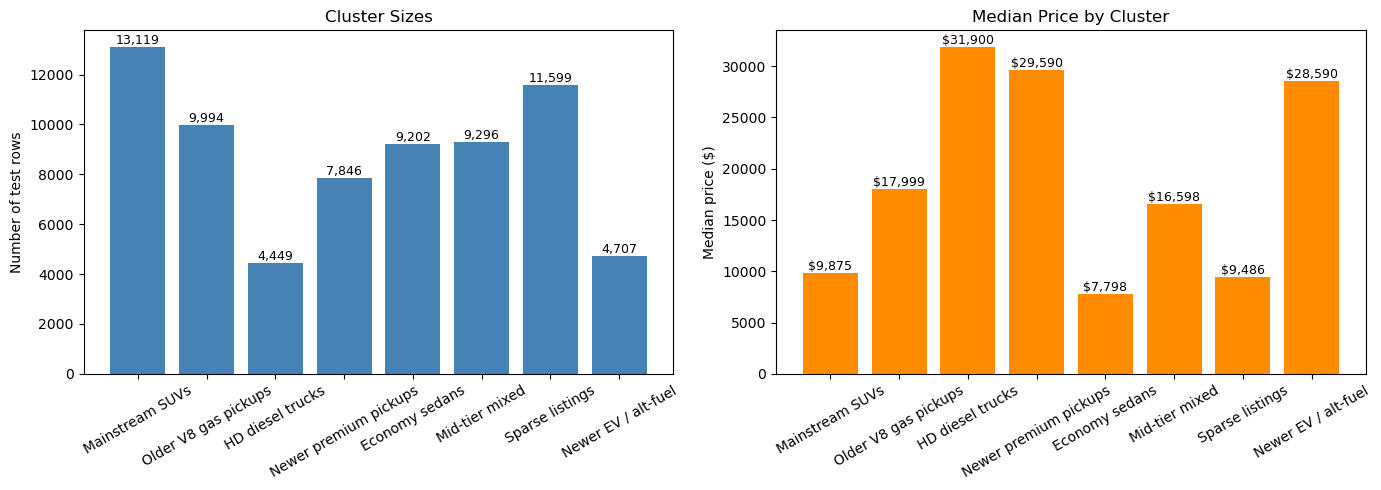

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_summary = plot_df.groupby(['cluster', 'cluster_label']).agg(
    n=('actual', 'size'),
    median_price=('actual', 'median'),
).reset_index().sort_values('cluster')

# Size
axes[0].bar(cluster_summary['cluster_label'], cluster_summary['n'], color='steelblue')
axes[0].set_ylabel('Number of test rows')
axes[0].set_title('Cluster Sizes')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(cluster_summary['n']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Median price
axes[1].bar(cluster_summary['cluster_label'], cluster_summary['median_price'], color='darkorange')
axes[1].set_ylabel('Median price ($)')
axes[1].set_title('Median Price by Cluster')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(cluster_summary['median_price']):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

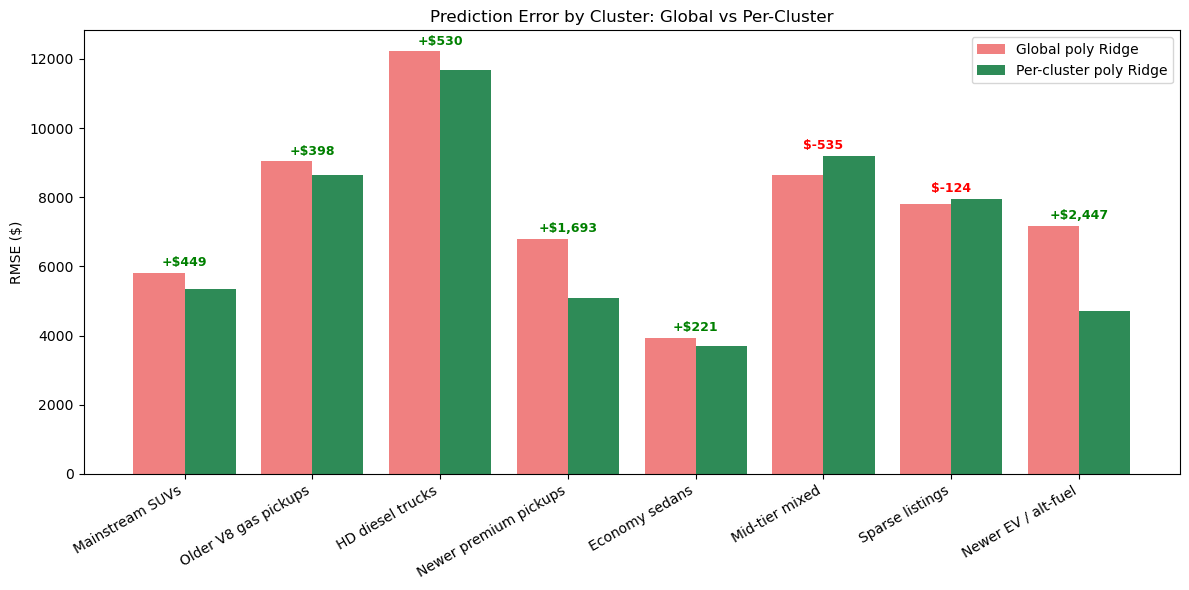

In [37]:
from sklearn.metrics import root_mean_squared_error

rows = []
for c, label in CLUSTER_LABELS.items():
    mask = plot_df['cluster'] == c
    if mask.sum() == 0:
        continue
    rmse_global  = root_mean_squared_error(plot_df.loc[mask, 'actual'], plot_df.loc[mask, 'pred_global'])
    rmse_cluster = root_mean_squared_error(plot_df.loc[mask, 'actual'], plot_df.loc[mask, 'pred_cluster'])
    rows.append({'cluster': c, 'label': label, 'global': rmse_global, 'per_cluster': rmse_cluster})

rmse_df = pd.DataFrame(rows).sort_values('cluster')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(rmse_df))
w = 0.4
ax.bar(x - w/2, rmse_df['global'],      width=w, label='Global poly Ridge',     color='lightcoral')
ax.bar(x + w/2, rmse_df['per_cluster'], width=w, label='Per-cluster poly Ridge', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(rmse_df['label'], rotation=30, ha='right')
ax.set_ylabel('RMSE ($)')
ax.set_title('Prediction Error by Cluster: Global vs Per-Cluster')
ax.legend()

# Annotate the delta
for i, row in rmse_df.reset_index().iterrows():
    delta = row['global'] - row['per_cluster']
    color = 'green' if delta > 0 else 'red'
    sym = '+' if delta > 0 else ''
    y = max(row['global'], row['per_cluster']) + 200
    ax.text(i, y, f'{sym}${delta:,.0f}', ha='center', color=color, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_539243/3969056794.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordered, showfliers=False, patch_artist=True)


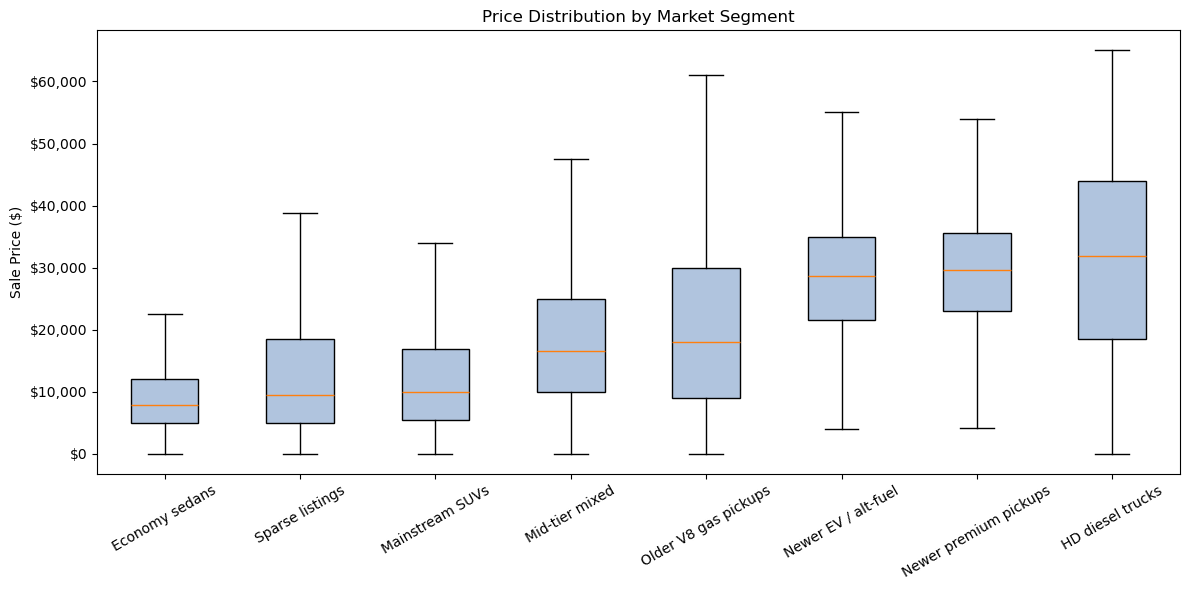

In [38]:
ordered = cluster_summary.sort_values('median_price')['cluster_label'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
data = [plot_df.loc[plot_df['cluster_label'] == lbl, 'actual'].values for lbl in ordered]
bp = ax.boxplot(data, labels=ordered, showfliers=False, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')

ax.set_ylabel('Sale Price ($)')
ax.set_title('Price Distribution by Market Segment')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

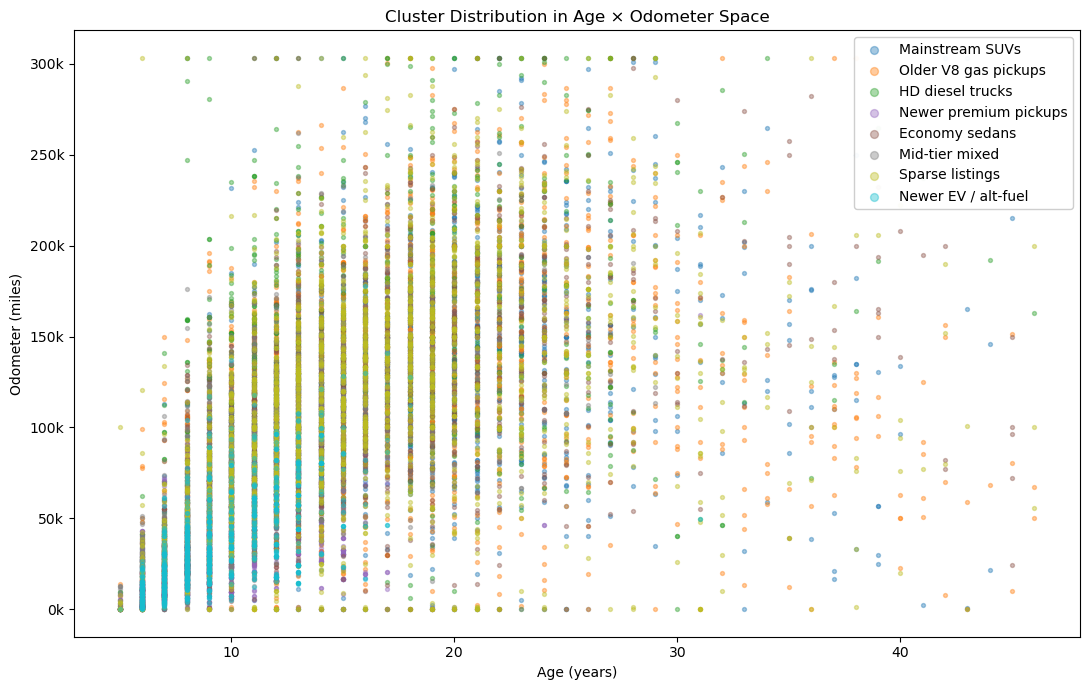

In [39]:
fig, ax = plt.subplots(figsize=(11, 7))
sample_idx = np.random.RandomState(42).choice(len(plot_df), size=15_000, replace=False)
sample = plot_df.iloc[sample_idx]

colors = plt.cm.tab10(np.linspace(0, 1, len(CLUSTER_LABELS)))
for c, label in CLUSTER_LABELS.items():
    mask = sample['cluster'] == c
    ax.scatter(sample.loc[mask, 'age'], sample.loc[mask, 'odometer'],
               c=[colors[c]], s=8, alpha=0.4, label=label)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Odometer (miles)')
ax.set_title('Cluster Distribution in Age × Odometer Space')
ax.legend(loc='upper right', markerscale=2, framealpha=0.95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

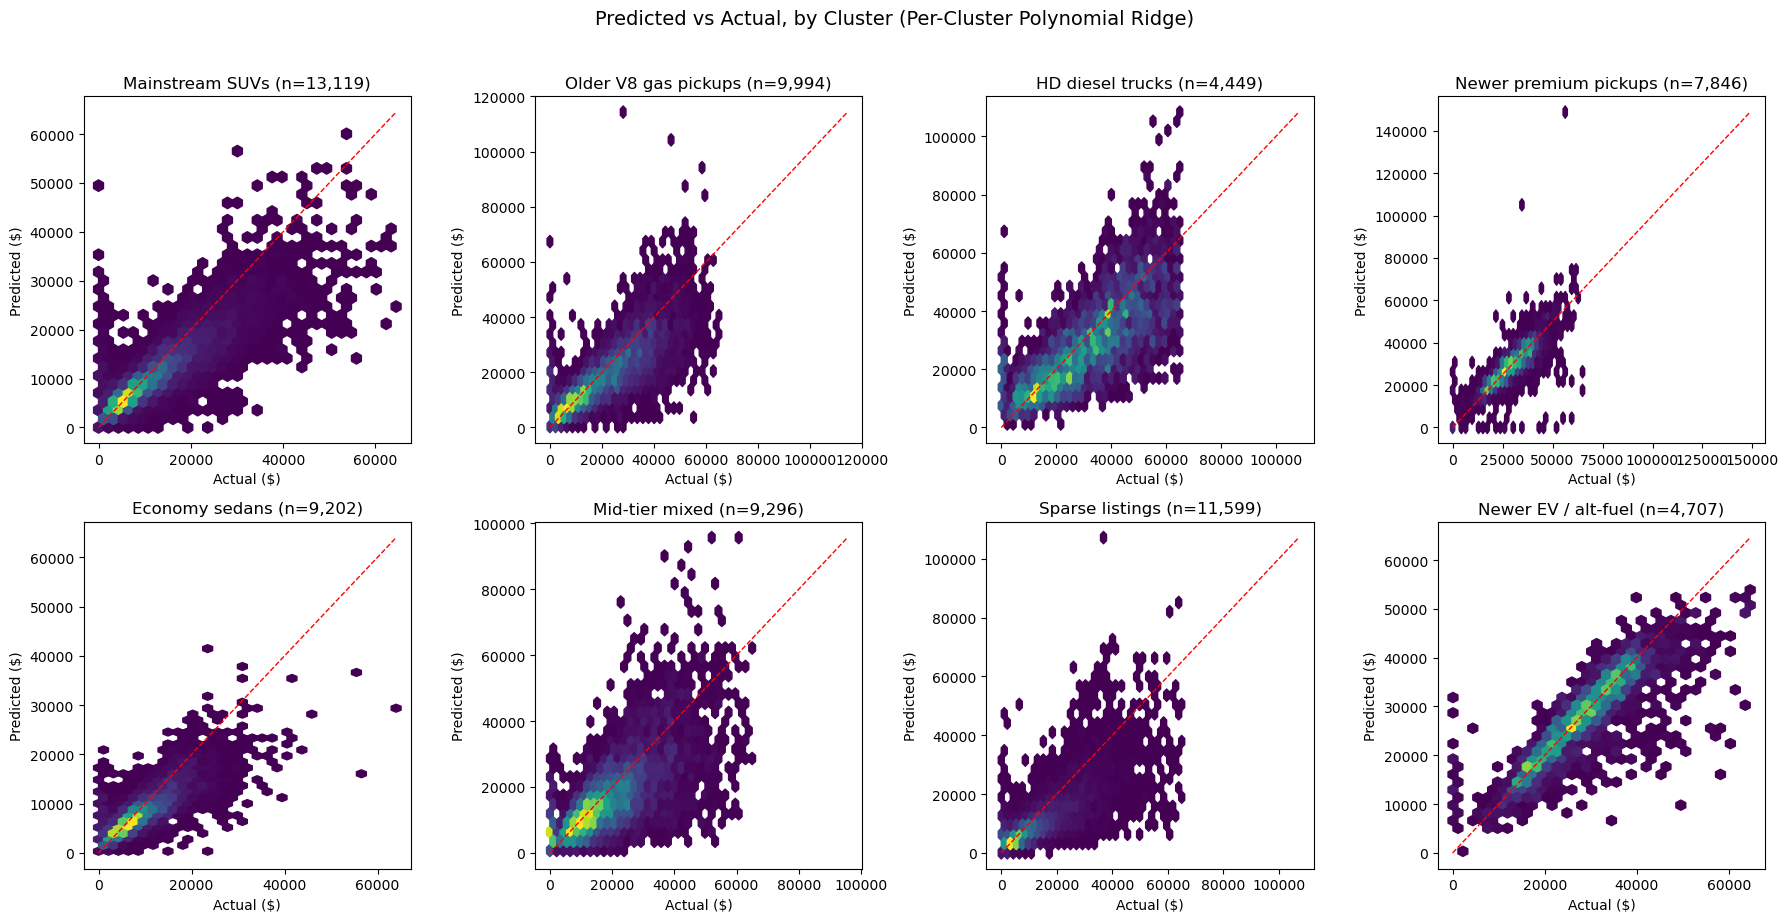

In [40]:
clusters = sorted(CLUSTER_LABELS.keys())
n_clusters = len(clusters)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, c in enumerate(clusters):
    ax = axes[i]
    sub = plot_df[plot_df['cluster'] == c]
    ax.hexbin(sub['actual'], sub['pred_cluster'], gridsize=30, cmap='viridis', mincnt=1)
    lim = max(sub['actual'].max(), sub['pred_cluster'].max())
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_title(f"{CLUSTER_LABELS[c]} (n={len(sub):,})")
    ax.set_xlabel('Actual ($)')
    ax.set_ylabel('Predicted ($)')

# Hide any extra empty subplots
for j in range(len(clusters), len(axes)):
    axes[j].axis('off')

plt.suptitle('Predicted vs Actual, by Cluster (Per-Cluster Polynomial Ridge)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

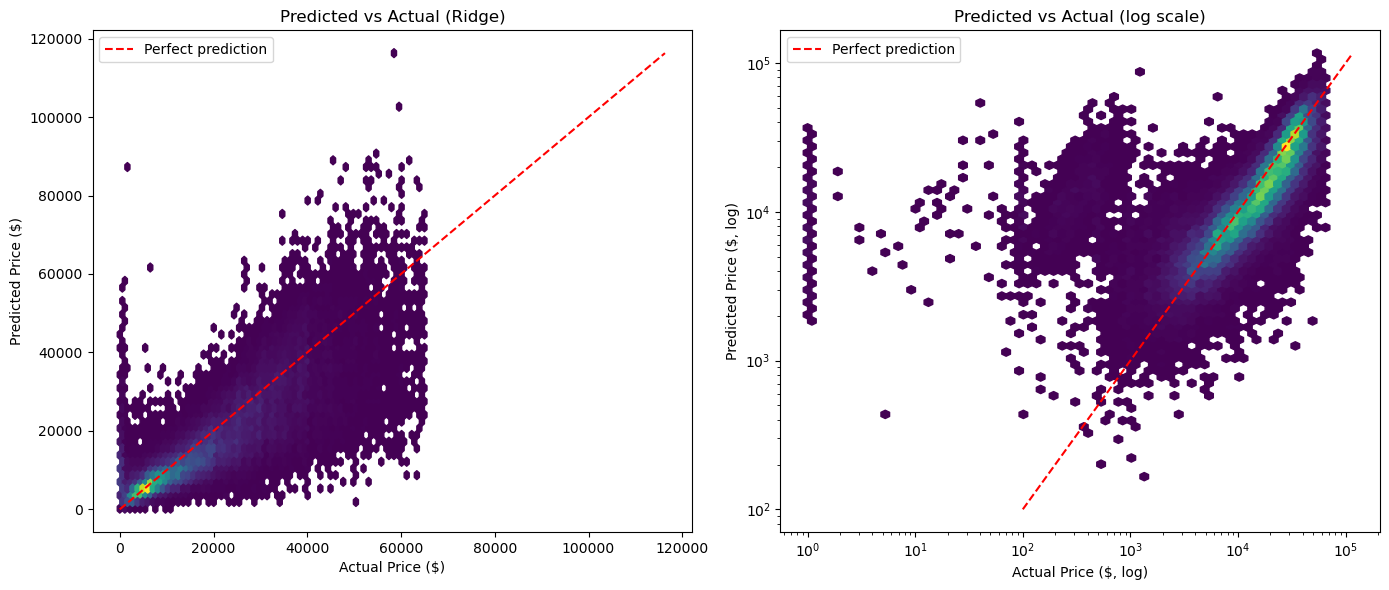

In [41]:
### plot the predicted prices against the actual prices

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

preds = preds_ridge_poly

# Linear-scale view
axes[0].hexbin(y_test, preds, gridsize=60, cmap='viridis', mincnt=1)
lim = max(y_test.max(), preds.max())
axes[0].plot([0, lim], [0, lim], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual (Ridge)')
axes[0].legend()

# Log-scale view — easier to see fit quality at low prices
axes[1].hexbin(y_test, preds, gridsize=60, cmap='viridis', mincnt=1, xscale='log', yscale='log')
axes[1].plot([100, lim], [100, lim], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual Price ($, log)')
axes[1].set_ylabel('Predicted Price ($, log)')
axes[1].set_title('Predicted vs Actual (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

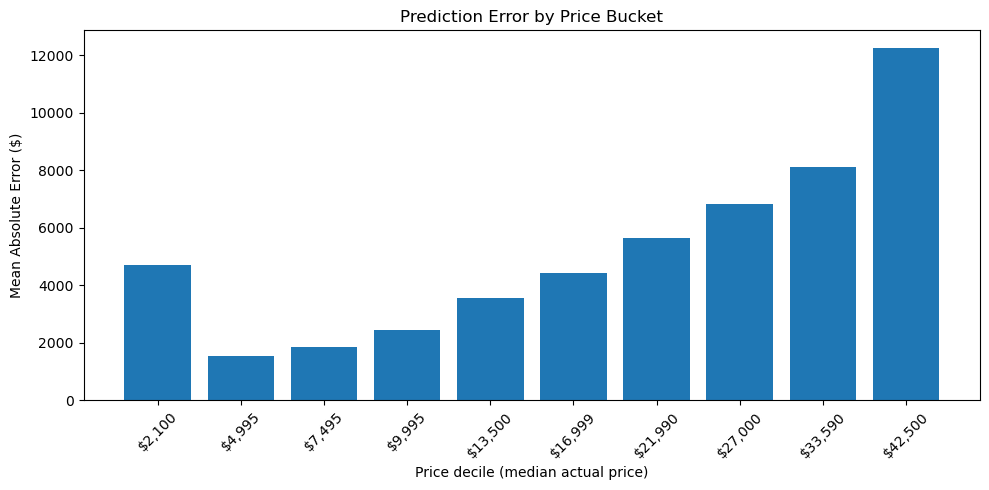

   bucket  median_actual  median_abs_error   mean_actual  mean_abs_error
0       0         2100.0       2147.130962   1937.307376     4714.555283
1       1         4995.0       1065.003910   5041.485671     1529.368907
2       2         7495.0       1464.131272   7392.661879     1839.401845
3       3         9995.0       2056.032860  10021.537299     2430.134289
4       4        13500.0       3227.493757  13501.759830     3560.256579
5       5        16999.0       4072.098099  17293.643847     4410.714232
6       6        21990.0       5135.769049  21870.554052     5627.463671
7       7        27000.0       5886.425089  27335.929373     6831.381341
8       8        33590.0       7105.258139  33517.278355     8125.020240
9       9        42500.0      10393.777149  44686.992867    12252.883785


In [42]:
### plot the prediction error split into different price buckets

buckets = pd.qcut(y_test, q=10, labels=False)
err_by_bucket = pd.DataFrame({
    'bucket': buckets,
    'actual': y_test.values,
    'predicted': preds,
    'abs_error': np.abs(y_test.values - preds),
})

bucket_summary = err_by_bucket.groupby('bucket').agg(
    median_actual=('actual', 'median'),
    median_abs_error=('abs_error', 'median'),
    mean_actual=('actual', 'mean'),
    mean_abs_error=('abs_error', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bucket_summary['bucket'], bucket_summary['mean_abs_error'])
ax.set_xticks(bucket_summary['bucket'])
ax.set_xticklabels([f"${m:,.0f}" for m in bucket_summary['median_actual']], rotation=45)
ax.set_xlabel('Price decile (median actual price)')
ax.set_ylabel('Mean Absolute Error ($)')
ax.set_title('Prediction Error by Price Bucket')
plt.tight_layout()
plt.show()

print(bucket_summary)

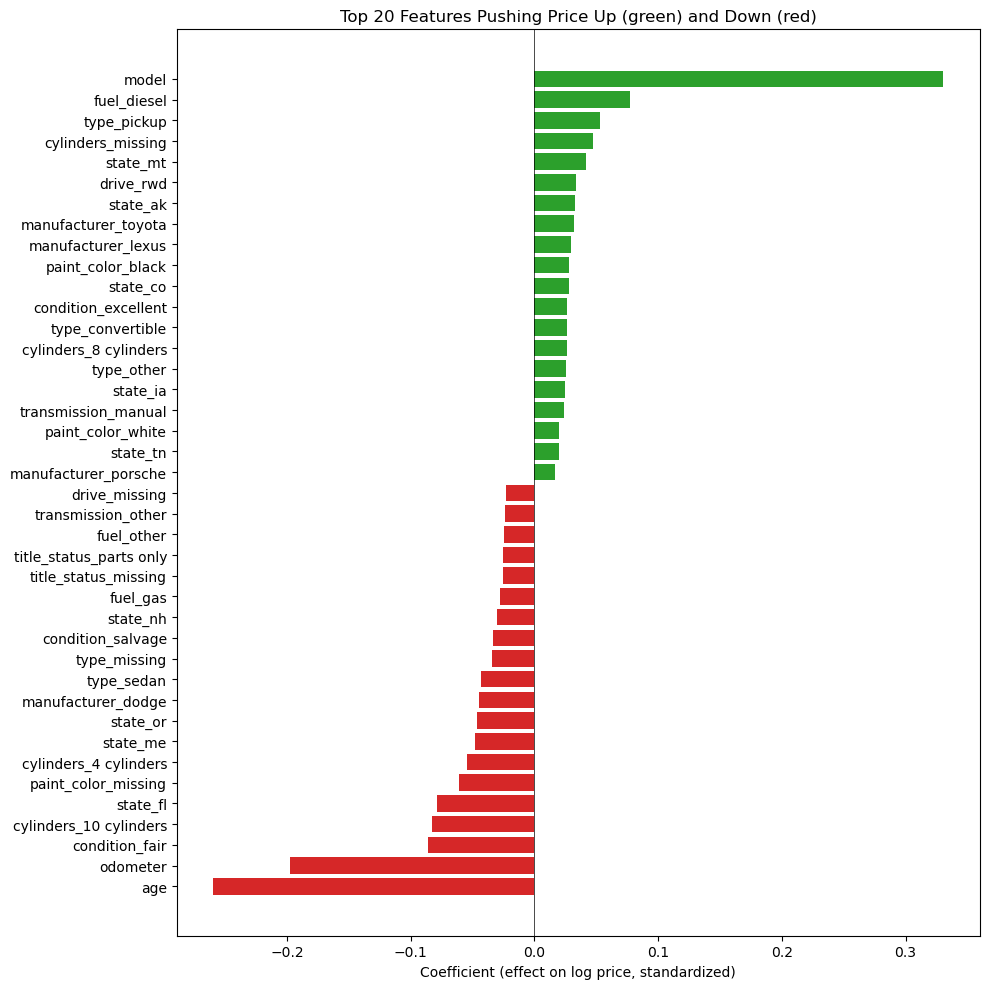

In [43]:
### plot the impact of the top 20 most impactful features using their coefficients

ridge_model = ridge_pipe.named_steps['ridge']
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ridge_model.coef_,
}).assign(abs_coef=lambda d: d['coefficient'].abs())

top_n = 20
top_pos = coef_df.nlargest(top_n, 'coefficient')
top_neg = coef_df.nsmallest(top_n, 'coefficient')
top_features = pd.concat([top_pos, top_neg]).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (effect on log price, standardized)')
ax.set_title(f'Top {top_n} Features Pushing Price Up (green) and Down (red)')
plt.tight_layout()
plt.show()

In [45]:
# Pull global Ridge coefficients into a Series indexed by feature
global_coefs = coef_df.set_index('feature')['coefficient']

# Build merged frame with delta vs global
merged = per_cluster_coefs.copy()
merged['global_coef']   = merged['feature'].map(global_coefs)
merged['delta']         = merged['coefficient'] - merged['global_coef']
merged['cluster_label'] = merged['cluster'].map(CLUSTER_LABELS)

merged.head()

,cluster,feature,coefficient,global_coef,delta,cluster_label
0,0,condition_excellent,0.039759,0.026417,0.013342,Mainstream SUVs
1,0,condition_fair,-0.106355,-0.085988,-0.020367,Mainstream SUVs
2,0,condition_good,-0.020836,0.000270,-0.021106,Mainstream SUVs
3,0,condition_like new,0.014757,0.008634,0.006123,Mainstream SUVs
4,0,condition_missing,0.009751,-0.001717,0.011469,Mainstream SUVs


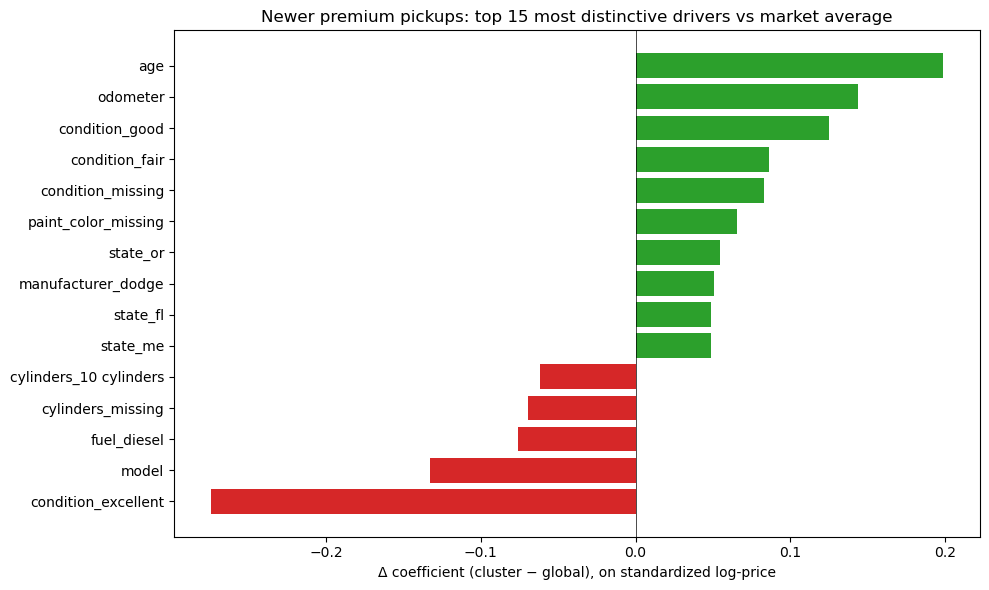

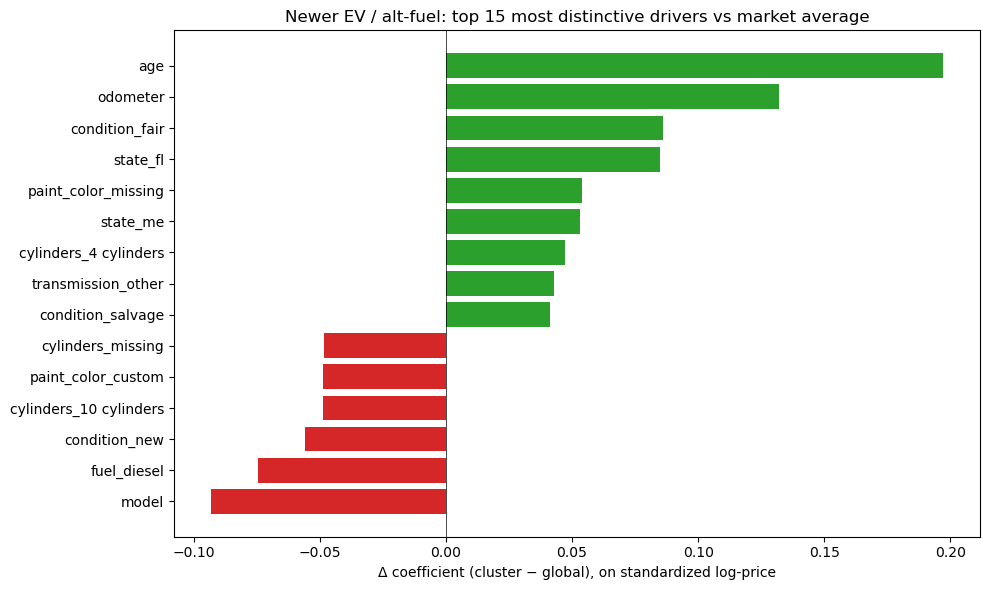

In [46]:
def plot_distinctive_drivers(cluster_id, n=15):
    """Top features whose coefficients differ most from the global Ridge model
    for this cluster — i.e., what makes this segment's pricing logic distinctive."""
    sub = merged[merged['cluster'] == cluster_id].copy()
    # Rank features by absolute delta
    sub = sub.reindex(sub['delta'].abs().sort_values(ascending=False).index).head(n)
    # Sort for plotting (most negative at bottom, most positive at top)
    sub = sub.sort_values('delta')

    colors = ['#d62728' if d < 0 else '#2ca02c' for d in sub['delta']]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sub['feature'], sub['delta'], color=colors)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Δ coefficient (cluster − global), on standardized log-price')
    ax.set_title(f"{CLUSTER_LABELS[cluster_id]}: top {n} most distinctive drivers vs market average")
    plt.tight_layout()
    plt.show()


# Plot the segments where per-cluster modeling helped most
for c in [3, 7]:   # K=8: Newer premium pickups, Newer EV / alt-fuel
    plot_distinctive_drivers(c)

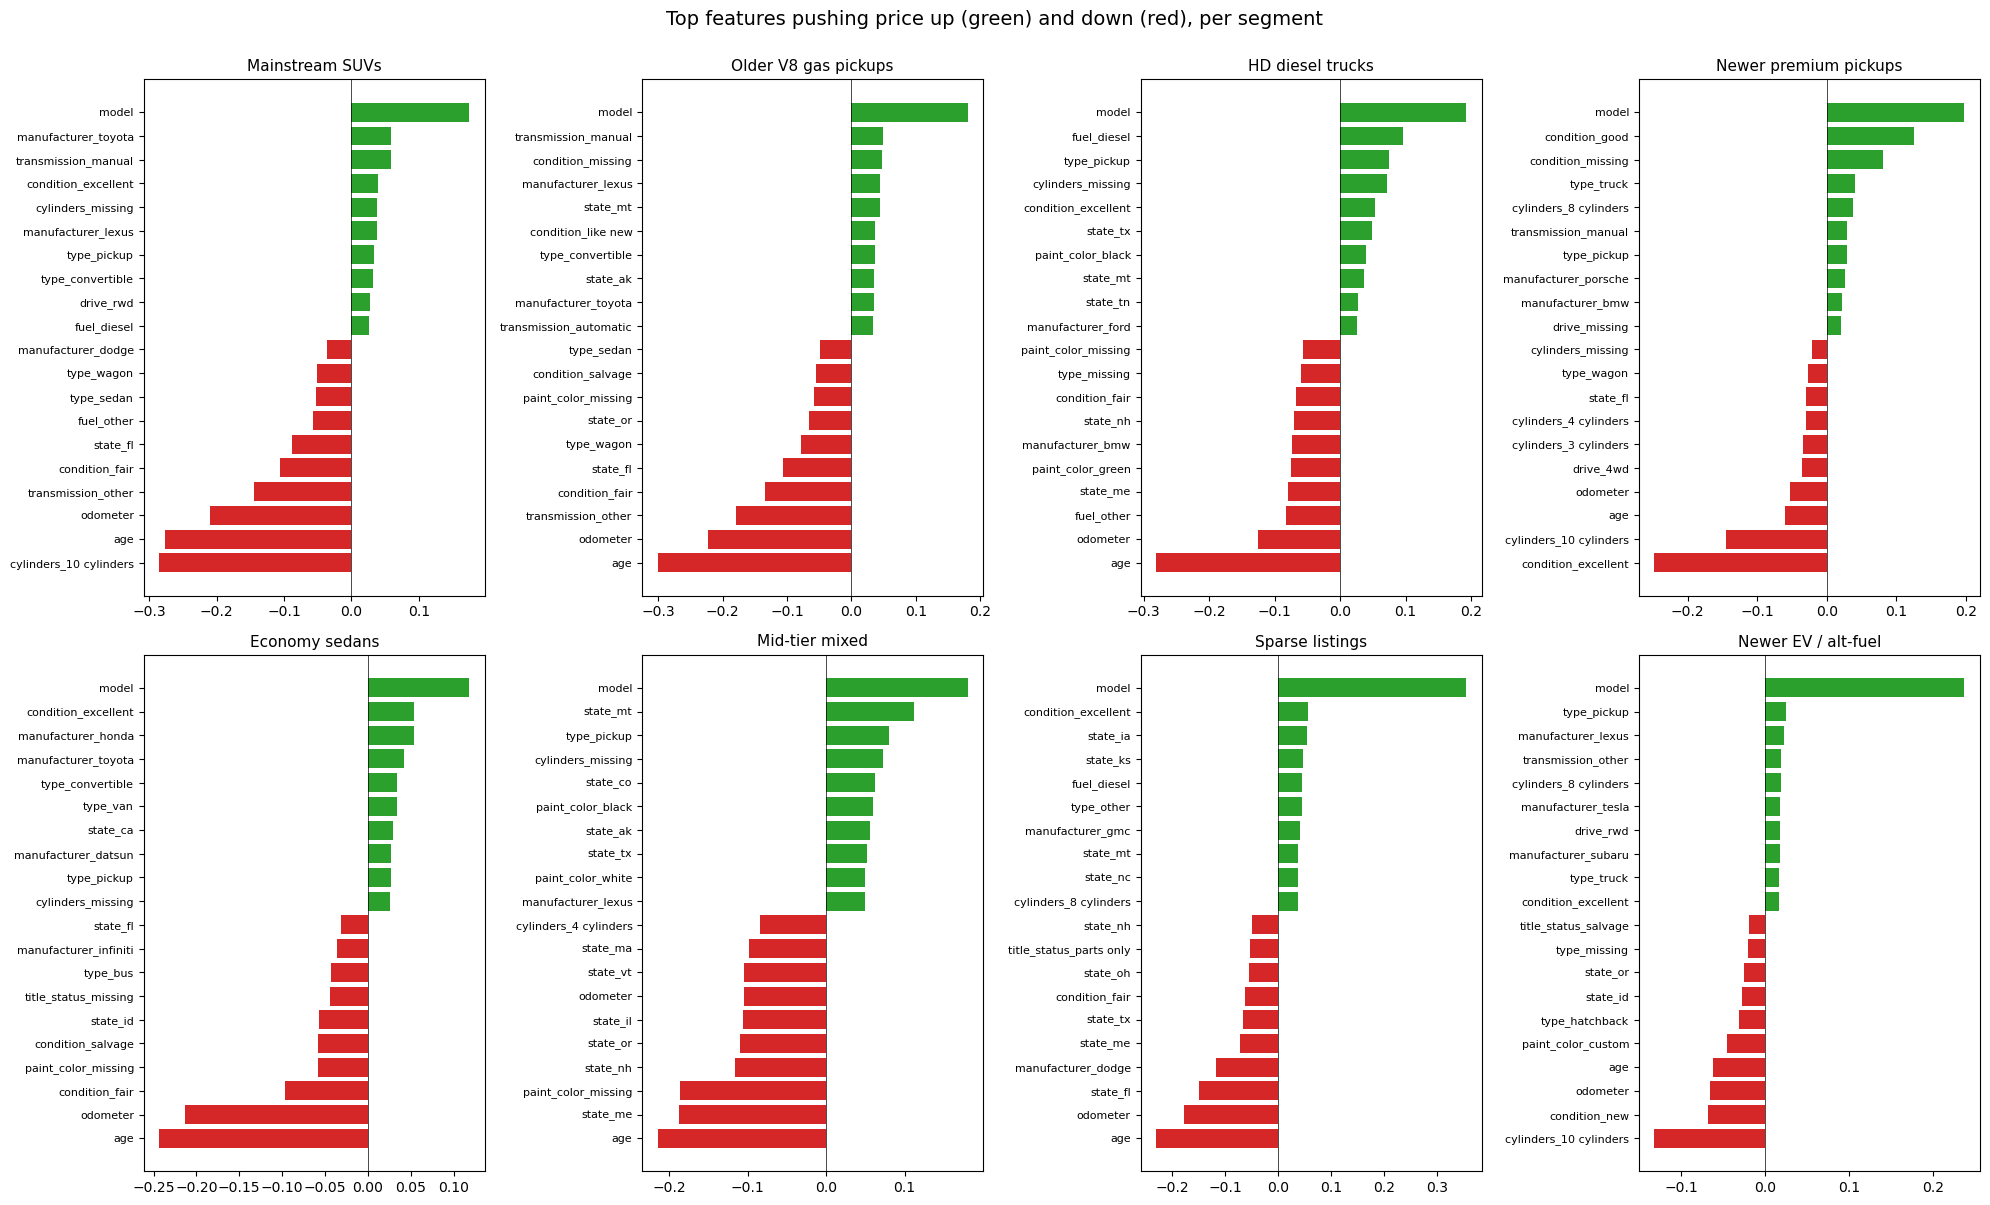

In [47]:
clusters = sorted(merged['cluster'].unique())
n_clusters = len(clusters)

# 2x4 grid for K=8; auto-adjust if you ever change K
ncols = 4
nrows = -(-n_clusters // ncols)   # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 6 * nrows))
axes = axes.flatten()

for i, c in enumerate(clusters):
    ax = axes[i]
    sub = merged[merged['cluster'] == c]
    top_pos = sub.nlargest(10, 'coefficient')
    top_neg = sub.nsmallest(10, 'coefficient')
    top     = pd.concat([top_pos, top_neg]).sort_values('coefficient')

    colors = ['#d62728' if v < 0 else '#2ca02c' for v in top['coefficient']]
    ax.barh(top['feature'], top['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(CLUSTER_LABELS[c], fontsize=11)
    ax.tick_params(axis='y', labelsize=8)

for j in range(n_clusters, len(axes)):
    axes[j].axis('off')

plt.suptitle('Top features pushing price up (green) and down (red), per segment', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

#### **Model Performance**

Six models were evaluated against a held-out 20% test set, all trained on `log(price)`:

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Baseline (median price) | $13,455 | $10,672 | -0.04 |
| Linear Regression | $8,497 | $5,485 | 0.584 |
| Ridge (CV-selected α=1,000) | $8,473 | $5,479 | 0.586 |
| Lasso (CV-selected α=0.001) | $8,453 | $5,458 | 0.588 |
| Ridge + Polynomial Features (numeric) | $7,614 | $5,128 | 0.666 |
| **Per-cluster Polynomial Ridge (K=8)** | **$7,239** | **$4,603** | **0.698** |

Key observations:

- All linear models substantially outperform the naive baseline — a ~46% reduction in RMSE for the best model.
- The plain Linear, Ridge, and Lasso models cluster within $50 of each other on RMSE. With n=285k training rows and only 156 features, regularization isn't doing much heavy lifting — the OLS solution is already near-optimal under the linear assumption.
- **Adding polynomial features on the three numeric columns (`odometer`, `age`, `model`)** delivered a $859 reduction in RMSE and an 8-point jump in R² over plain Ridge. This confirms that the relationship between mileage/age and price is meaningfully non-linear — depreciation accelerates with age and mileage rather than being constant.
- **Fitting the polynomial Ridge separately on each of 8 KMeans-derived market segments** added another $375 RMSE reduction. The improvement is concentrated in two segments where pricing dynamics differ meaningfully from the global average: newer EV/alt-fuel vehicles (+$2,447 vs global) and newer premium gas pickups (+$1,693 vs global). Six of the eight clusters benefit from per-cluster modeling; the two that don't (a heterogeneous mid-tier mix and the sparse-listings cluster) are essentially ties or small losses.
- Lasso retains 134 of 156 features at its CV-selected α, suggesting most encoded features carry at least some signal even if individual contributions are small.

#### **Business Objective Assessment**

Returning to the original business question asking which factors most impact used car prices, the per-cluster polynomial Ridge model explains roughly 70% of the variance in used car prices, with a median absolute error of ~$4,600. This is very useful for inventory-level guidance — the model identifies which vehicle attributes affect the final sale price the most, providing valuable insight for dealerships.

The model is most accurate on mid-priced vehicles ($10k–$30k) and progressively less accurate at the high and low end, which is to be expected of a model trained on `log(price)`.

The model is useful as a general inventory-level price guidance (e.g., "what features should we prioritize when sourcing?") but is **not** as useful for informing individual vehicle sales (e.g., "set the asking price for this specific car"). The remaining ~30% of price variance is likely explained by factors the dataset does not capture: listing photos, exact trim level, free-text descriptions, market timing, regional supply/demand, and listing quality.

#### **Interpretability vs. Predictive Power**

The per-cluster polynomial Ridge model is the most accurate, but its coefficients are split across squared and interaction terms within each segment-specific model, which complicates direct interpretation. For the per-feature recommendations the plain Ridge model is more useful — its coefficients have a clean one-to-one relationship with features. We use the per-cluster polynomial Ridge to validate that our model is capable of accurate predictions, and the plain Ridge to produce the interpretable feature-importance rankings that drive the dealer recommendations.

#### **Should Earlier Phases Be Revisited?**

A few revisions would likely improve performance further:

1. **Reconsider the price clipping window.** The current upper bound of $68,747 (99th percentile) excludes a small but real luxury market. Lifting the cap to the 99.9th percentile (~$123k) preserves more signal at the cost of more outlier risk.
2. **Engineer additional interactions for the linear model.** The polynomial step only added interactions among the three numeric features. Cross-product terms like `manufacturer × age` or `type × odometer` could capture brand- and category-specific depreciation patterns.
3. **Source additional features for the heavy-duty truck segment.** Heavy-duty diesel trucks (Cluster 2) remain the hardest segment to fit, with a per-cluster RMSE of ~$11,700 — exact engine variant, trim level, and tow package matter substantially within this segment but aren't captured in the dataset.
4. **Try a tree-based model.** A Gradient Boosting Regressor on the same feature matrix would likely push R² to ~0.80–0.85 by capturing non-linear effects across all features (not just the three numeric ones), at the cost of less direct coefficient interpretability.

In [44]:
import joblib, json
from pathlib import Path

ART = Path('../artifacts')
(ART / 'data').mkdir(parents=True, exist_ok=True)
(ART / 'models').mkdir(parents=True, exist_ok=True)

# Data splits (post-encoding, ready for modeling)
X_train.to_parquet(ART / 'data/X_train.parquet')
X_test.to_parquet(ART / 'data/X_test.parquet')
y_train.to_frame('price').to_parquet(ART / 'data/y_train.parquet')
y_test.to_frame('price').to_parquet(ART / 'data/y_test.parquet')

# Fitted artifacts
joblib.dump(ridge_poly,                ART / 'models/ridge_poly.pkl')
joblib.dump(kmeans,                    ART / 'models/kmeans.pkl')
joblib.dump(pca,                       ART / 'models/pca.pkl')
joblib.dump(scaler,                    ART / 'models/scaler.pkl')
joblib.dump(encoder,                   ART / 'models/target_encoder.pkl')
joblib.dump(per_cluster_pipelines,     ART / 'models/per_cluster_pipelines.pkl')

# Predictions and assignments — bundle them so the report has one DataFrame
pd.DataFrame({
    'actual':       y_test.values,
    'pred_global':  preds_ridge_poly,
    'pred_cluster': preds_combined,
    'cluster':      clusters_test,
    'odometer':     X_test['odometer'].values,
    'age':          X_test['age'].values,
}).to_parquet(ART / 'predictions.parquet')

# Coefficients for the top-drivers chart
coef_df.to_parquet(ART / 'coefficients.parquet')

# Save coefficients as a single DataFrame for the report
coef_records = []
for c, pipe in per_cluster_plain_ridge.items():
    coefs = pipe.named_steps['ridge'].coef_
    for feat, coef in zip(X_train.columns, coefs):
        coef_records.append({'cluster': c, 'feature': feat, 'coefficient': coef})
per_cluster_coefs = pd.DataFrame(coef_records)
per_cluster_coefs.to_parquet(ART / 'per_cluster_coefficients.parquet')

# Aggregate metrics — useful when the report wants to cite numbers in prose
metrics = {
    'global_polynomial_ridge': {'rmse': 7614, 'mae': 5128, 'r2': 0.666},
    'per_cluster_polynomial_ridge': {'rmse': 7463, 'mae': 4728, 'r2': 0.679},
    'cluster_count': 7,
    'n_train': int(len(X_train)),
    'n_test':  int(len(X_test)),
}
with open(ART / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)